In [7]:
from typing import Dict, List
import numpy as np
import pandas as pd
from scipy.stats import pearsonr # pyright: ignore[reportMissingTypeStubs, reportUnknownVariableType]

from model_ranking.results import (
    get_summary_results, 
    per_source_model_results,
    results_to_arrays,
)
from model_ranking.plots import plot_alpha_sweep_specific_norm
from model_ranking.correlation import (
    scores_to_rank, 
    permutation_test_kendall_tau, 
    permutation_test_spearman_rho,
    calculate_correlation_statistics,
)

# Foreground consistency

In [8]:
NA_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys2 = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"],
    #"DO": ["a01"]
}
invert_consis = False
invert_perf = False
rank_ascending = False
perf_tolerance = 0
consis_tolerance = 0
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito", "VNC"]
#targets = ["EPFL"]
#targets = ["Rmito"]
#targets = ["VNC"]
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
summary_results_postfix = "_full"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 21.34it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.14it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 22.31it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 23.04it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 21.90it/s]


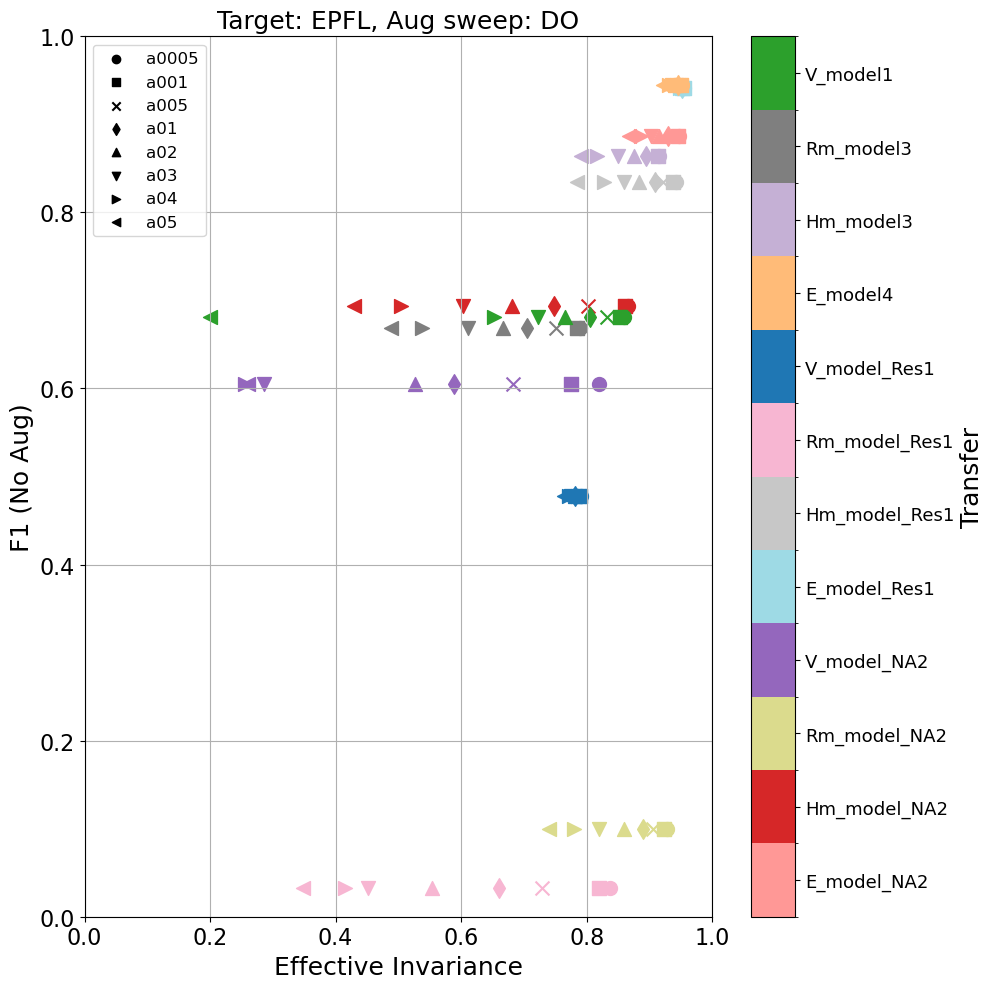

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 18.75it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.38it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 20.63it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 20.83it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 20.88it/s]


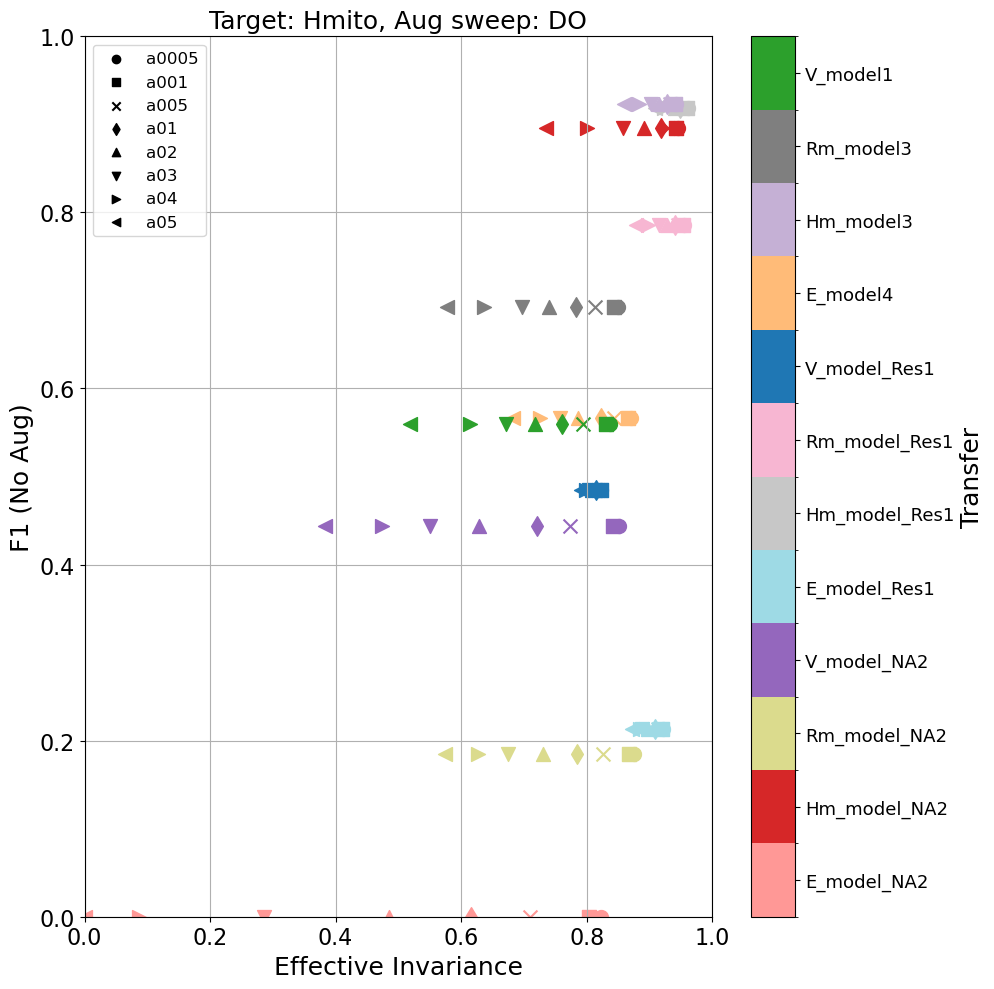

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 19.53it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.68it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 23.12it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 19.96it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 18.96it/s]


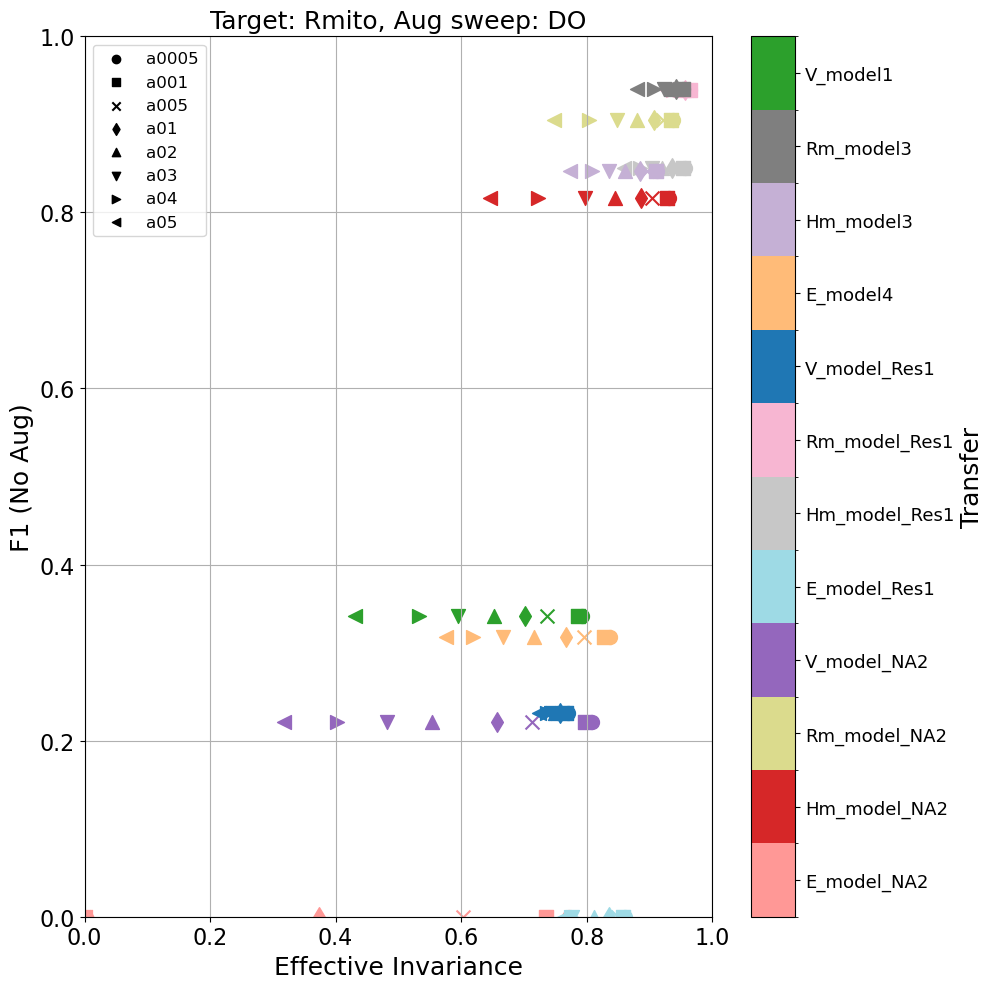

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 19.83it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.56it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 20.87it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 20.50it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 22.77it/s]


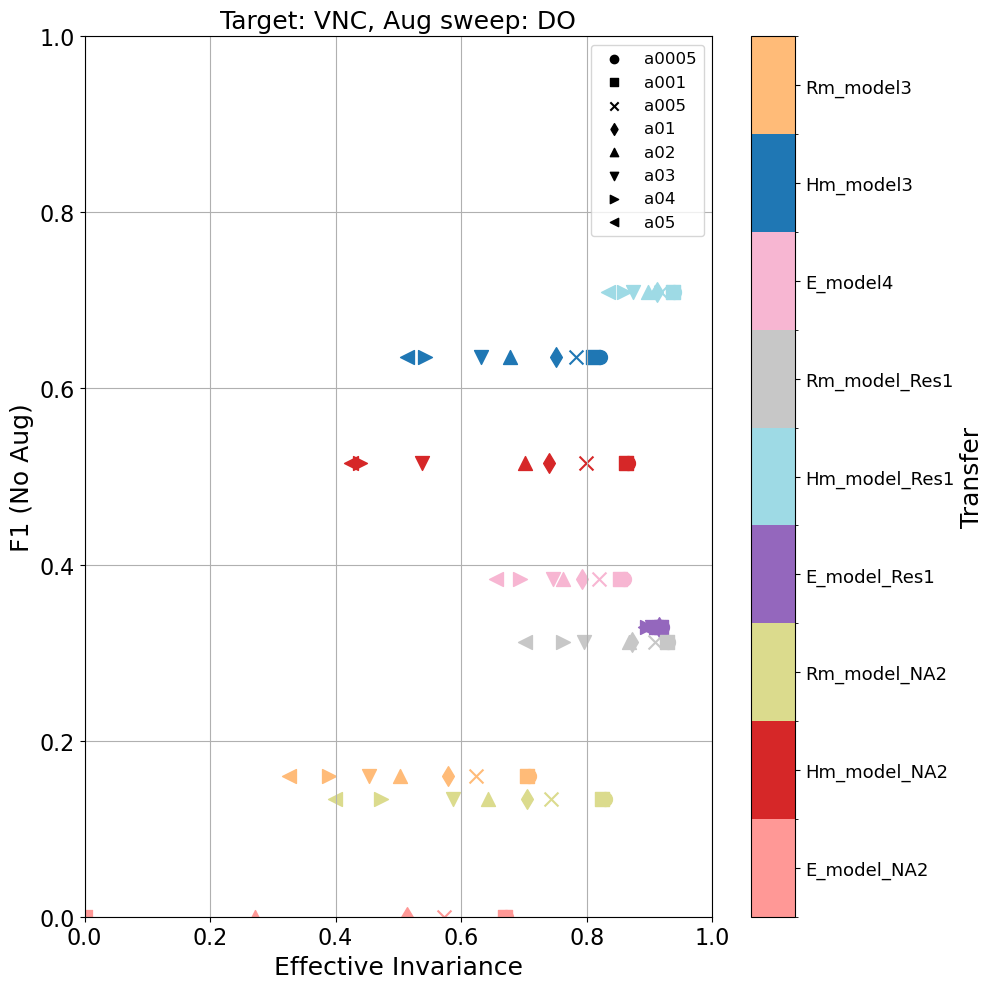

In [9]:
single_target_consistency = {}
single_target_performance = {}
kendall_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
k_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
spearman_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
sp_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
pearson_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
p_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_consistency = {}
    per_source_performance = {}
    consis_str_NAmodels, _, NA_perf_NAmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = NA_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_NAmodels, 
            source_models=NA_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_NAmodels, 
            source_models=NA_source_models,
        ))
    
    consis_str_Resmodels, _, NA_perf_Resmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = Res_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_Resmodels, 
            source_models=Res_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_Resmodels, 
            source_models=Res_source_models,
        ))
    
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys2,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str_VNC, _, NA_per_VNC = get_summary_results(
            source_data=["VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str.update(consis_str_VNC)
        NA_perf.update(NA_per_VNC)
    
    per_source_consistency.update(
        per_source_model_results(
            consis_str, 
            source_models=source_models,
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf,
            source_models=source_models,
        ))
    
    single_target_consistency[target] = per_source_consistency
    single_target_performance[target] = per_source_performance

    plot_alpha_sweep_specific_norm(
        per_source_consistency,
        per_source_performance,
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

    consis_scores, NA_perf_scores = results_to_arrays(
        per_source_consistency, per_source_performance, "DO", len(selected_augmentations["DO"])
    )
    # print(f"Consistency scores shape: {consis_scores.shape}")
    # print("consistency_score")
    # print(consis_scores)
    # print("Performance Score")
    # print(NA_perf_scores)

    if invert_consis:
        consis_scores = 1 - consis_scores
    if invert_perf:
        NA_perf_scores = 1 - NA_perf_scores

    target_df = pd.DataFrame()
    target_df['aug_strength'] = selected_augmentations["DO"]
    ken_scores = np.zeros(consis_scores.shape[1])
    ken_pvalue = np.zeros(consis_scores.shape[1])
    spear_scores = np.zeros(consis_scores.shape[1])
    spear_pval = np.zeros(consis_scores.shape[1])
    pearsons_scores = np.zeros(consis_scores.shape[1])
    pearsons_pval = np.zeros(consis_scores.shape[1])
    for j in range(consis_scores.shape[1]):
        #print(f"Consis Tolerance {consis_tolerance}")
        #print(f"Aug strength {selected_augmentations['DO'][j]}, Target {target}")
        #print(f"performance scores { NA_perf_scores}")
        ranked_scores = scores_to_rank(NA_perf_scores, ascending=rank_ascending, tolerance=perf_tolerance)
        #print(f"ranked scores {ranked_scores}")
        #print(f"ranked scores {ranked_scores}")
        #print(f"consistency scores {consis_scores[:, j]}")
        ranked_consis = scores_to_rank(consis_scores[:, j],ascending=rank_ascending, tolerance=consis_tolerance)
        #print(f"ranked consistency {ranked_consis}")
        #print(f"ranked consistency {ranked_consis}")
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, consis_scores[:, i])
        pearson, pearson_pval = pearsonr(NA_perf_scores, consis_scores[:,j])
        #print(f"Pearson r: {pearson}, p-value: {pearson_pval}")
        spearman, spearmans_pval = permutation_test_spearman_rho(ranked_scores, ranked_consis)
        #print(f"Spearman rho: {spearman}, p-value: {spearmans_pval}")
        ken, pval = permutation_test_kendall_tau(ranked_scores, ranked_consis)
        #print(f"Kendall tau: {ken}, p-value: {pval}")
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, ranked_consis)
        #print(f"{selected_augmentations['DO'][j]}: p={pearson:.3f}, s={spearman:.3f}, k{ken:.3f}")
        
        #print(f"{selected_augmentations['DO'][j]}: ken{ken:.3f}, pvalue={pval:.3f}")
        #print("\n")
        ken_scores[j] = ken
        ken_pvalue[j] = pval
        spear_scores[j] = spearman
        spear_pval[j] = spearmans_pval
        pearsons_scores[j] = pearson
        pearsons_pval[j] = pearson_pval
    target_df["kendall tau"] = ken_scores
    target_df["kendall p-value"] = ken_pvalue
    target_df["spearman rho"] = spear_scores
    target_df["spearman p-value"] = spear_pval
    target_df["pearson r"] = pearsons_scores
    target_df["pearson p-value"] = pearsons_pval
    kendall_per_transfer[i] = ken_scores
    k_pval_per_transfer[i] = ken_pvalue
    spearman_per_transfer[i] = spear_scores
    sp_pval_per_transfer[i] = spear_pval
    pearson_per_transfer[i] = pearsons_scores
    p_pval_per_transfer[i] = pearsons_pval

In [4]:
per_target_KT = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_SP = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_PE = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
for i, target in enumerate(targets):
    (per_target_PE[i], 
        per_target_SP[i], 
        per_target_KT[i]
    ) = calculate_correlation_statistics(
            single_target_consistency[target],
            single_target_performance[target],
            selected_augmentations,
            perturbation_key="DO",
        )

In [5]:
aug_strengths = selected_augmentations["DO"]
for aug_strength in aug_strengths:
    idx = selected_augmentations["DO"].index(aug_strength)
    df = pd.DataFrame(
        {
            "kt": per_target_KT[:, idx, 0], 
            "kt pval": per_target_KT[:, idx, 1], 
            "s rho": per_target_SP[:, idx, 0], 
            "s rho pval": per_target_SP[:, idx, 1], 
            "pr": per_target_PE[:, idx, 0], 
            "pr pval": per_target_PE[:, idx, 1]
        },
    )
    df["targets"] = targets
    df = df.set_index("targets")
    df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
    # Round all float columns to 2 significant figures
    df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
    print(f"Augmentation strength: DO {aug_strength}")
    print(df)

Augmentation strength: DO a0005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.61     0.01   0.75        0.02  0.43     0.16
     Hmito    0.45     0.03   0.65        0.03  0.63     0.03
     Rmito    0.63     0.00   0.82        0.00  0.89     0.00
     VNC      0.39     0.16   0.57        0.13  0.65     0.06
Augmentation strength: DO a001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.61     0.01   0.75        0.01  0.45     0.14
     Hmito    0.48     0.03   0.68        0.01  0.65     0.02
     Rmito    0.66     0.00   0.84        0.00  0.90     0.00
     VNC      0.39     0.19   0.57        0.11  0.64     0.06
Augmentation strength: DO a005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.64     0.01   0.78    

In [6]:
aug_strength = "a005"
idx = selected_augmentations["DO"].index(aug_strength)
df = pd.DataFrame(
    {"kt": kendall_per_transfer[:,idx], "kt pval": k_pval_per_transfer[:,idx], "s rho": spearman_per_transfer[:,idx], "s rho pval": sp_pval_per_transfer[:,idx], "pr": pearson_per_transfer[:,idx], "pr pval": p_pval_per_transfer[:,idx]},
)
df["targets"] = targets
# make targets index
df = df.set_index("targets")
#add multi index to dataframe with a single index named Nuclei that covers all rows
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.64     0.01   0.78        0.00  0.51     0.09
     Hmito    0.55     0.02   0.72        0.01  0.70     0.01
     Rmito    0.72     0.00   0.87        0.00  0.85     0.00
     VNC      0.44     0.12   0.67        0.06  0.67     0.05


# Background consistency

In [16]:
NA_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
consis_keys={
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
consis_keys2 = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"],
}
invert_consis = False
invert_perf = False
rank_ascending = False
perf_tolerance = 0
consis_tolerance = 0
targets = ["EPFL", "Hmito", "Rmito"]
#targets = ["Rmito", "VNC"]
#targets = ["EPFL"]
#targets = ["VNC"]
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
summary_results_postfix = "_full"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 17.49it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 21.59it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 22.87it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 19.65it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 15.02it/s]


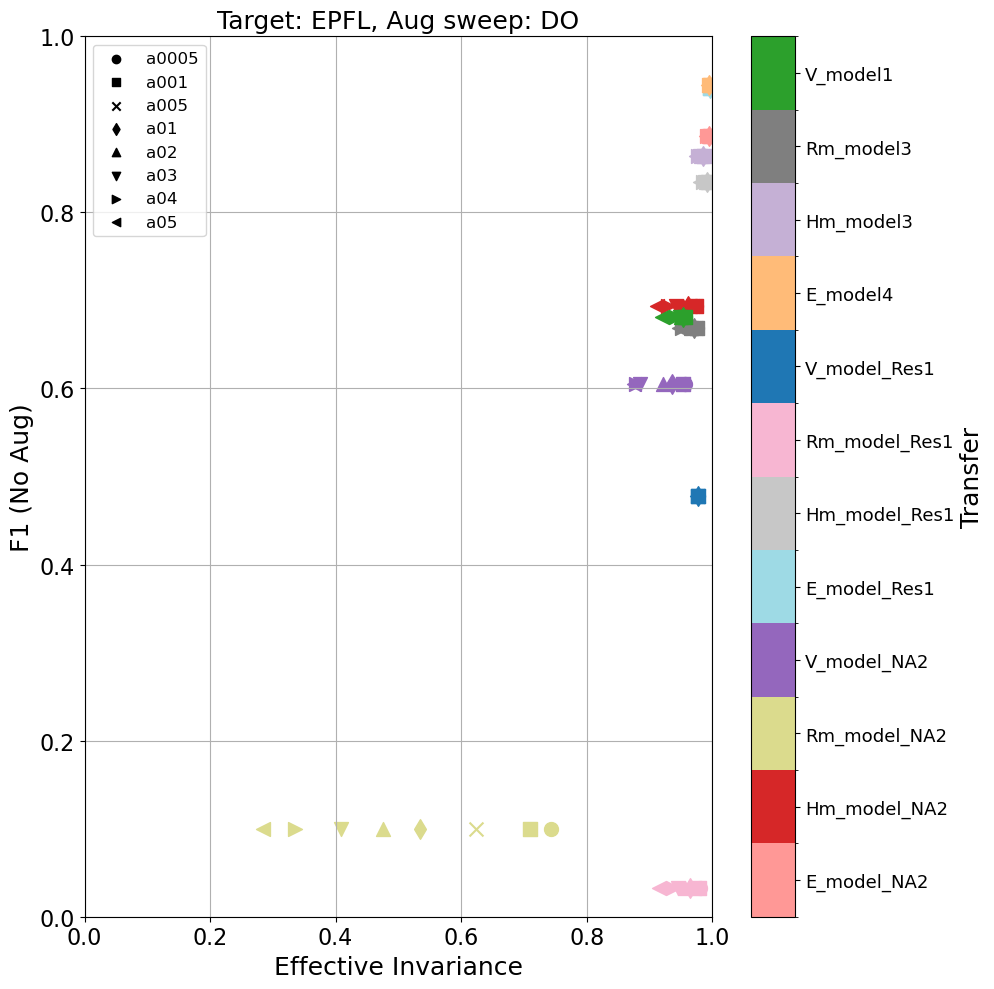

Source: EPFL


100%|██████████| 1/1 [00:00<00:00,  6.67it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  6.99it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00,  5.69it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  5.45it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00,  6.81it/s]


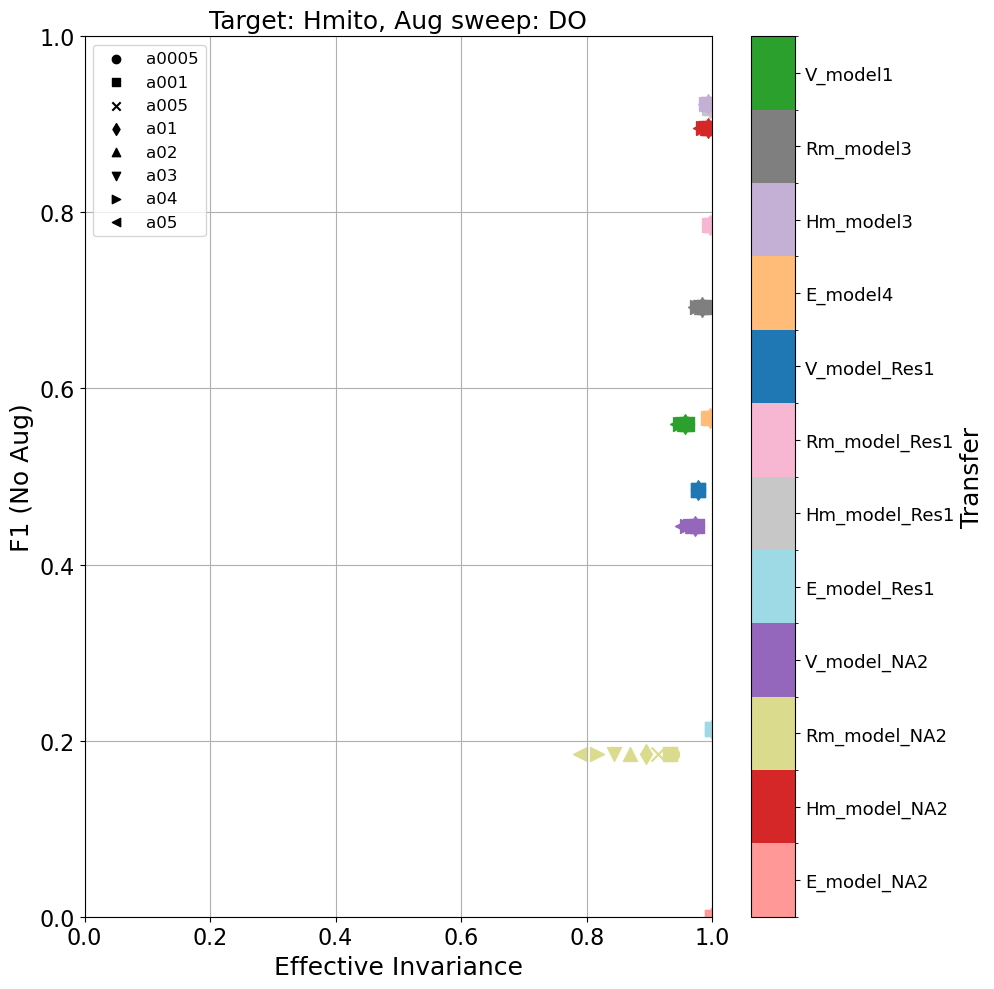

Source: EPFL


100%|██████████| 1/1 [00:00<00:00,  5.33it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  5.42it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00,  7.15it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  7.63it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00,  7.53it/s]


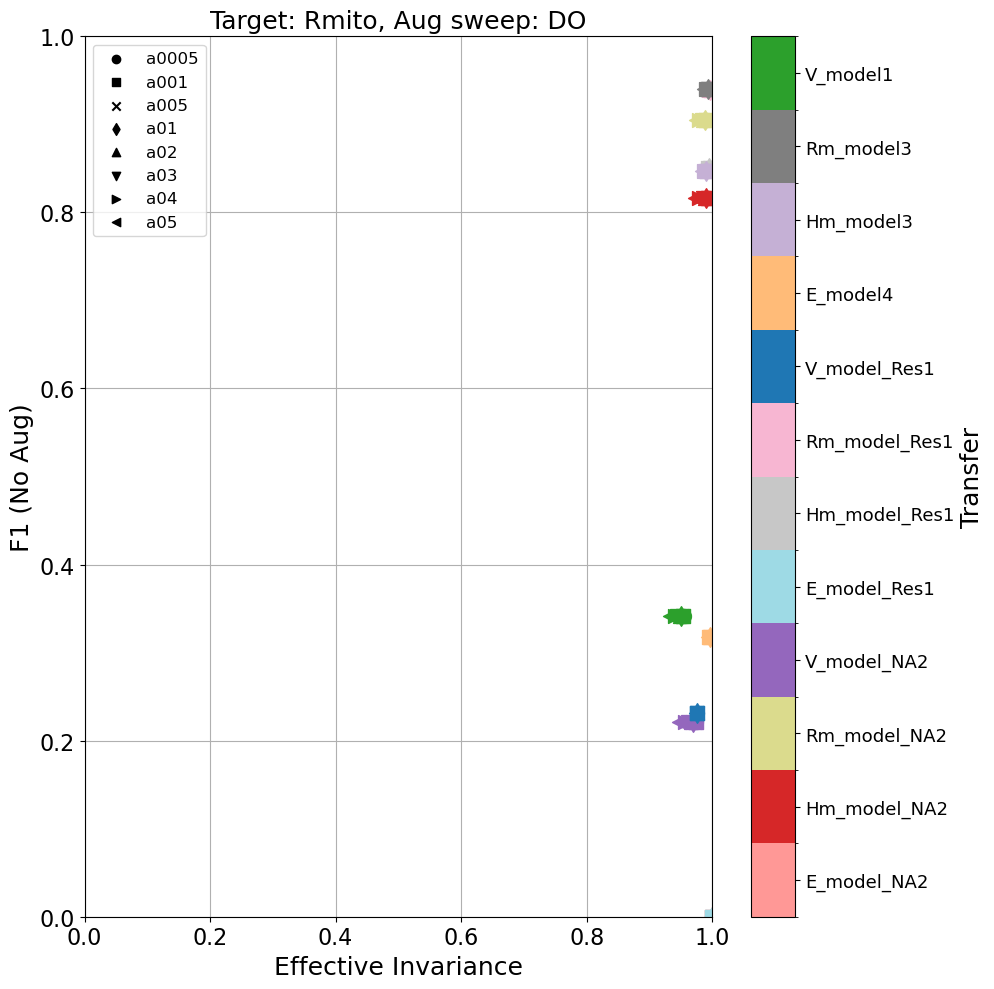

In [ ]:
single_target_consistency = {}
single_target_performance = {}
kendall_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
k_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
spearman_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
sp_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
pearson_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
p_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_consistency = {}
    per_source_performance = {}
    consis_str_NAmodels, _, NA_perf_NAmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = NA_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_NAmodels, 
            source_models=NA_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_NAmodels, 
            source_models=NA_source_models,
        ))
    
    consis_str_Resmodels, _, NA_perf_Resmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = Res_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_Resmodels, 
            source_models=Res_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_Resmodels, 
            source_models=Res_source_models,
        ))
    
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito", "VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    
    per_source_consistency.update(
        per_source_model_results(
            consis_str, 
            source_models=source_models,
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf,
            source_models=source_models,
        ))
    
    single_target_consistency[target] = per_source_consistency
    single_target_performance[target] = per_source_performance

    plot_alpha_sweep_specific_norm(
        per_source_consistency,
        per_source_performance,
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

    consis_scores, NA_perf_scores = results_to_arrays(
        per_source_consistency, per_source_performance, "DO", len(selected_augmentations["DO"])
    )
    if invert_consis:
        consis_scores = 1 - consis_scores
    if invert_perf:
        NA_perf_scores = 1 - NA_perf_scores

    target_df = pd.DataFrame()
    target_df['aug_strength'] = selected_augmentations["DO"]
    ken_scores = np.zeros(consis_scores.shape[1])
    ken_pvalue = np.zeros(consis_scores.shape[1])
    spear_scores = np.zeros(consis_scores.shape[1])
    spear_pval = np.zeros(consis_scores.shape[1])
    pearsons_scores = np.zeros(consis_scores.shape[1])
    pearsons_pval = np.zeros(consis_scores.shape[1])
    for j in range(consis_scores.shape[1]):
        #print(f"Consis Tolerance {consis_tolerance}")
        #print(f"Aug strength {selected_augmentations['DO'][j]}, Target {target}")
        #print(f"performance scores { NA_perf_scores}")
        ranked_scores = scores_to_rank(NA_perf_scores, ascending=rank_ascending, tolerance=perf_tolerance)
        #print(f"ranked scores {ranked_scores}")
        #print(f"consistency scores {consis_scores[:, j]}")
        ranked_consis = scores_to_rank(consis_scores[:, j],ascending=rank_ascending, tolerance=consis_tolerance)
        #print(f"ranked consistency {ranked_consis}")
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, consis_scores[:, i])
        pearson, pearson_pval = pearsonr(NA_perf_scores, consis_scores[:,j])
        spearman, spearmans_pval = permutation_test_spearman_rho(ranked_scores, ranked_consis)
        ken, pval = permutation_test_kendall_tau(ranked_scores, ranked_consis)
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, ranked_consis)
        #print(f"{selected_augmentations['DO'][j]}: p={pearson:.3f}, s={spearman:.3f}, k{ken:.3f}")
        
        #print(f"{selected_augmentations['DO'][j]}: ken{ken:.3f}, pvalue={pval:.3f}")
        #print("\n")
        ken_scores[j] = ken
        ken_pvalue[j] = pval
        spear_scores[j] = spearman
        spear_pval[j] = spearmans_pval
        pearsons_scores[j] = pearson
        pearsons_pval[j] = pearson_pval
    target_df["kendall tau"] = ken_scores
    target_df["kendall p-value"] = ken_pvalue
    target_df["spearman rho"] = spear_scores
    target_df["spearman p-value"] = spear_pval
    target_df["pearson r"] = pearsons_scores
    target_df["pearson p-value"] = pearsons_pval
    kendall_per_transfer[i] = ken_scores
    k_pval_per_transfer[i] = ken_pvalue
    spearman_per_transfer[i] = spear_scores
    sp_pval_per_transfer[i] = spear_pval
    pearson_per_transfer[i] = pearsons_scores
    p_pval_per_transfer[i] = pearsons_pval